# Análisis Exploratorio de Datos — Dry Bean Dataset (UCI 602)

**Proyecto:** Laboratorio Dry Bean ML  
**Metodología:** CRISP-DM — Fase 2: Comprensión de datos  
**Dataset:** Dry Bean Dataset, UCI Machine Learning Repository, id 602  
**Variable objetivo:** `Class`  
**Equipo:** Jenifer Ramos, Juan Velasquez, Yan Cuaran, Frank Daza  

---

Este notebook cubre la fase de comprensión de datos dentro del ciclo CRISP-DM.
El objetivo es conocer bien el dataset antes de pasar a la preparación y el modelado:
qué tan limpio está, cómo se distribuyen las clases, y qué relaciones existen entre las variables.

## 1. Contexto del dataset

El **Dry Bean Dataset** fue recopilado para clasificar automáticamente siete variedades
de frijol seco (*Phaseolus vulgaris*) a partir de imágenes de alta resolución.
Cada instancia representa un grano individual descrito por 16 características morfológicas
(área, perímetro, compacidad, etc.).

| Atributo       | Valor                                                         |
|----------------|---------------------------------------------------------------|
| Fuente         | UCI Machine Learning Repository (id 602)                     |
| Instancias     | 13,611                                                        |
| Features       | 16 (todas numéricas continuas)                                |
| Clases         | 7: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA       |
| Variable obj.  | `Class`                                                       |
| Valores nulos  | Ninguno reportado en la fuente original                       |

**Relevancia para el laboratorio:** se busca construir un clasificador multiclase
que maximice el F1 macro, métrica robusta ante posible desbalance entre clases.

## 2. Carga de datos

Primero importamos las librerías que vamos a usar a lo largo del notebook y configuramos el estilo de las gráficas.
También definimos la carpeta donde se guardarán las figuras generadas durante el análisis.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Estilo visual uniforme para todas las gráficas del notebook
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Carpeta donde se guardan las figuras generadas
REPORTS_DIR = Path('../outputs/reports/eda')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

Con las librerías listas, cargamos el dataset usando `fetch_drybean()`. Esta función descarga los datos desde UCI o los lee desde caché local si ya fueron descargados antes, lo que evita descargas repetidas.

In [2]:
import sys
sys.path.append('..')

from src.data_loading import fetch_drybean

# Si los datos ya fueron descargados antes, se leen desde caché para no repetir la descarga
CACHE_DIR = Path('../data/raw')
X, y, df = fetch_drybean(cache_dir=CACHE_DIR)

print(f'Dataset cargado correctamente.')
print(f'  Features (X): {X.shape}')
print(f'  Etiquetas (y): {y.shape}')
print(f'  DataFrame completo (df): {df.shape}')

Dataset cargado correctamente.
  Features (X): (13611, 16)
  Etiquetas (y): (13611,)
  DataFrame completo (df): (13611, 17)


El dataset cargó correctamente con 13,611 instancias y 17 columnas (16 features + la variable objetivo `Class`). A partir de aquí trabajamos con `X` para las features, `y` para las etiquetas y `df` cuando necesitamos el dataset completo.

## 3. Estructura y calidad de los datos

Antes de analizar los datos en profundidad, revisamos cómo está organizado el dataset: cuántas filas y columnas tiene, de qué tipo son los datos, si hay valores faltantes y si existen filas repetidas. Esto nos da una idea clara del estado en que llega la información.

In [3]:
# Confirmamos que el dataset cargó con las dimensiones y tipos esperados
print('=== Dimensiones ===')
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')

print('\n=== Tipos de datos ===')
print(df.dtypes)

=== Dimensiones ===
Filas: 13611  |  Columnas: 17

=== Tipos de datos ===
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRatio        float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
Roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object


El dataset tiene 13,611 filas y 17 columnas. Las 16 features son numéricas (enteras o decimales) y la columna `Class` es de tipo texto con el nombre de cada variedad. No hay tipos de datos inesperados, lo que facilita el preprocesamiento.

In [4]:
print('=== Valores nulos por columna ===')
nulos = df.isnull().sum()
# Si hay nulos los mostramos por columna; si no hay ninguno lo indicamos directamente
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos.')

print(f'\n=== Duplicados ===')
# Contamos cuántas filas son copia exacta de otra
duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {duplicados}')

=== Valores nulos por columna ===
Sin valores nulos.

=== Duplicados ===
Filas duplicadas: 68


No hay valores nulos en ninguna columna, lo cual es una buena señal. Sin embargo, se encontraron 68 filas duplicadas (menos del 1% del total) que conviene eliminar antes del entrenamiento para evitar que el modelo aprenda dos veces de los mismos ejemplos.

In [5]:
print('=== Estadísticas descriptivas ===')
# La transpuesta (.T) pone cada variable en una fila, más fácil de comparar
df.describe().T

=== Estadísticas descriptivas ===


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRatio,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


El resumen estadístico confirma que las features tienen escalas muy distintas: `Area` llega hasta 254,616 mientras que `Roundness` y `Compactness` están entre 0 y 1. Esto es importante tenerlo en cuenta para el modelado, ya que algoritmos como la regresión logística son sensibles a estas diferencias de escala.

## 4. Distribución de la variable objetivo `Class`

Revisamos cuántos ejemplos hay por clase. Cuando el dataset no está balanceado, algunas métricas como la exactitud (accuracy) pueden ser engañosas, por eso es importante entender bien esta distribución antes de elegir cómo evaluar el modelo.

In [6]:
conteo_clases = df['Class'].value_counts()
porcentaje_clases = df['Class'].value_counts(normalize=True) * 100

# Combinamos cantidad y porcentaje en una sola tabla para ver el desbalance de un vistazo
resumen_clases = pd.DataFrame({
    'Cantidad': conteo_clases,
    'Porcentaje (%)': porcentaje_clases.round(2)
})
print(resumen_clases)
print(f'\nTotal de instancias: {len(df)}')

          Cantidad  Porcentaje (%)
Class                             
DERMASON      3546           26.05
SIRA          2636           19.37
SEKER         2027           14.89
HOROZ         1928           14.17
CALI          1630           11.98
BARBUNYA      1322            9.71
BOMBAY         522            3.84

Total de instancias: 13611


La clase más frecuente es DERMASON con el 26% de los datos, y la menos frecuente es BOMBAY con apenas el 3.84%. Hay un desbalance moderado que justifica usar F1 macro como métrica principal. El siguiente gráfico lo muestra de forma visual.

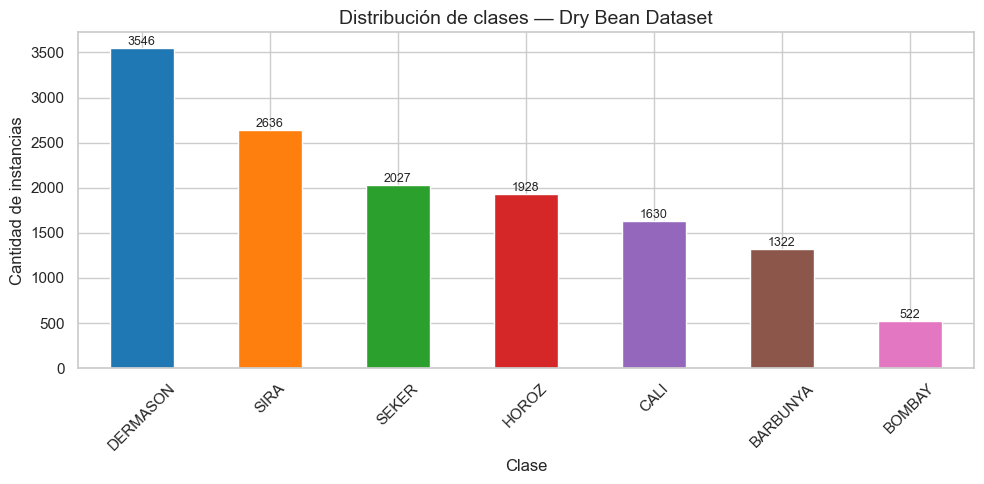

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
conteo_clases.plot(kind='bar', ax=ax, color=sns.color_palette('tab10', len(conteo_clases)))
ax.set_title('Distribución de clases — Dry Bean Dataset', fontsize=14)
ax.set_xlabel('Clase')
ax.set_ylabel('Cantidad de instancias')
ax.tick_params(axis='x', rotation=45)
# Anotamos el conteo exacto encima de cada barra para no tener que leerlo del eje
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distribucion_clases.png', bbox_inches='tight')
plt.show()

## 5. Análisis univariado — distribución de features

Graficamos la distribución de cada una de las 16 variables por separado. Esto nos ayuda a ver si tienen forma de campana, si están sesgadas hacia algún lado o si hay valores muy alejados del resto.

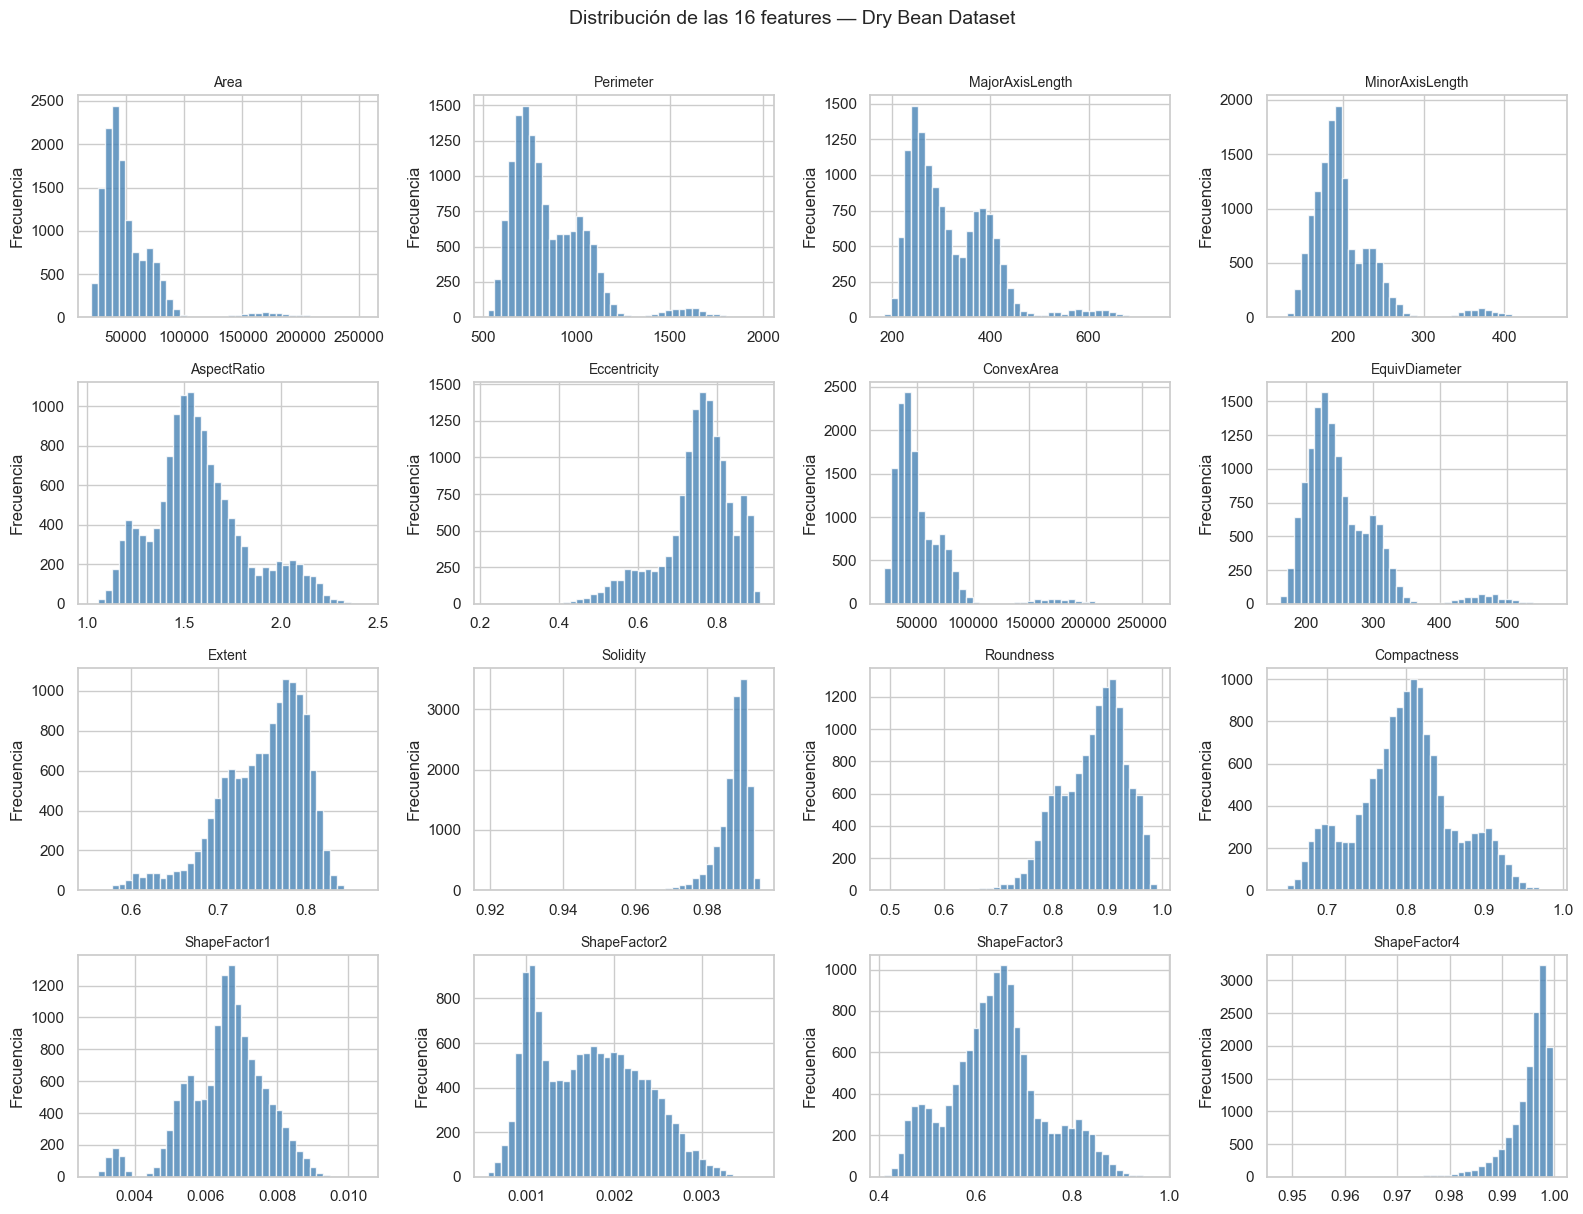

In [8]:
features = X.columns.tolist()
n_cols = 4
# División con redondeo hacia arriba para no perder la última fila de gráficas
n_rows = -(-len(features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(X[feature], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# Ocultamos los subplots que sobran al final de la grilla
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de las 16 features — Dry Bean Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distribucion_features.png', bbox_inches='tight')
plt.show()

Varias features como `Area`, `Perimeter` y `MajorAxisLength` muestran distribuciones con más de un pico, lo que tiene sentido porque cada pico corresponde aproximadamente a una variedad de frijol. Features como `Roundness` y `Compactness` tienen distribuciones más concentradas y simétricas.

## 6. Análisis bivariado — correlación y boxplots por clase

Ahora miramos cómo se relacionan las variables entre sí y cómo se comportan según la clase. Primero calculamos la correlación entre todas las features, y luego usamos boxplots para ver qué tan bien separan a las distintas variedades.

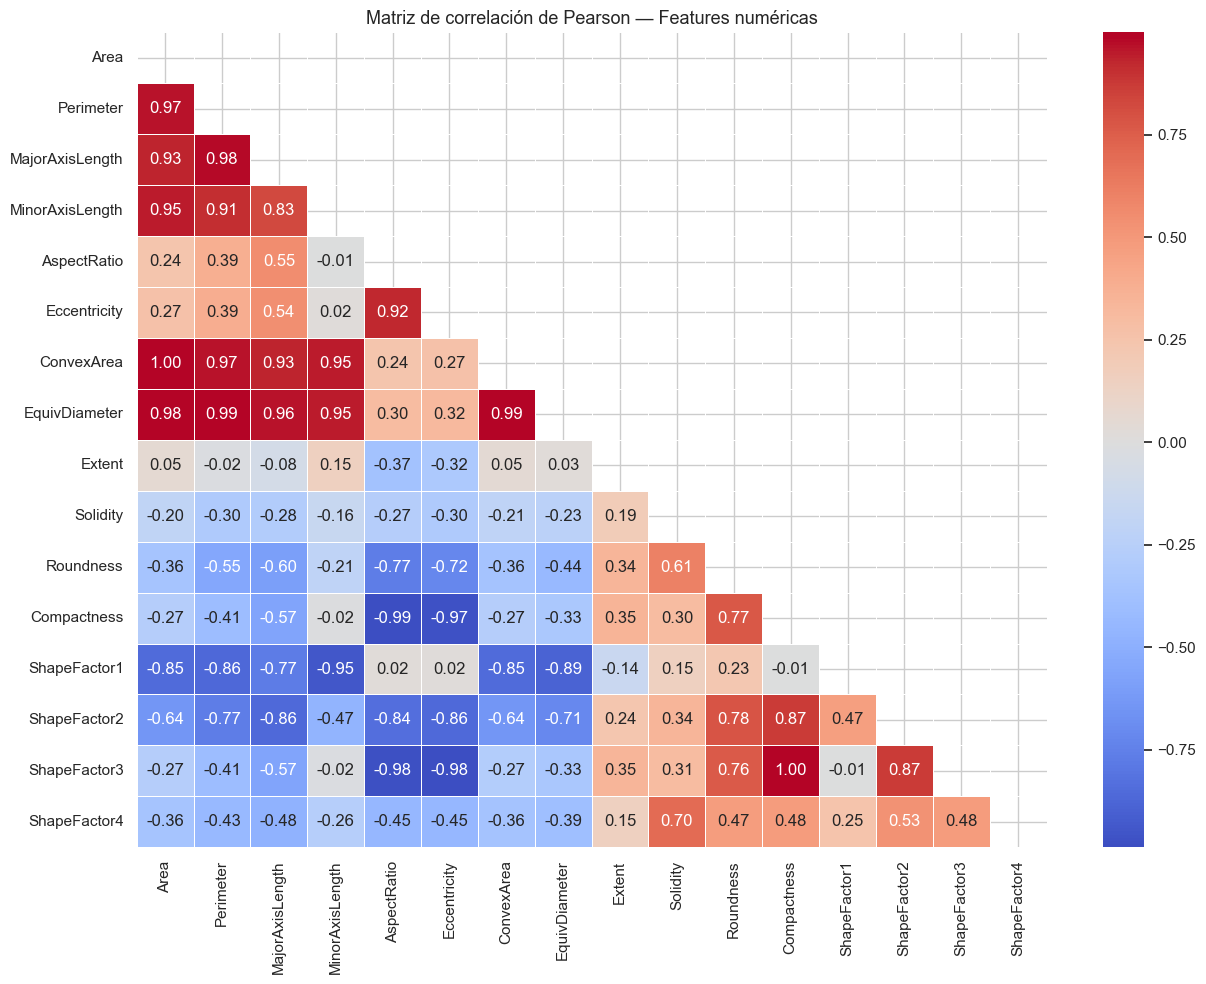

In [9]:
corr_matrix = X.corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 10))
# La máscara oculta el triángulo superior para no mostrar el mismo valor dos veces
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de correlación de Pearson — Features numéricas', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'matriz_correlacion.png', bbox_inches='tight')
plt.show()

El mapa de calor muestra que `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength` y `ConvexArea` están muy correlacionadas entre sí (por encima de 0.9). Básicamente miden lo mismo desde ángulos distintos. Para el modelo de regresión logística esto no es un problema grave gracias al escalado, pero es bueno tenerlo en cuenta. Ahora veamos cómo se distribuyen algunas de estas variables según la clase.

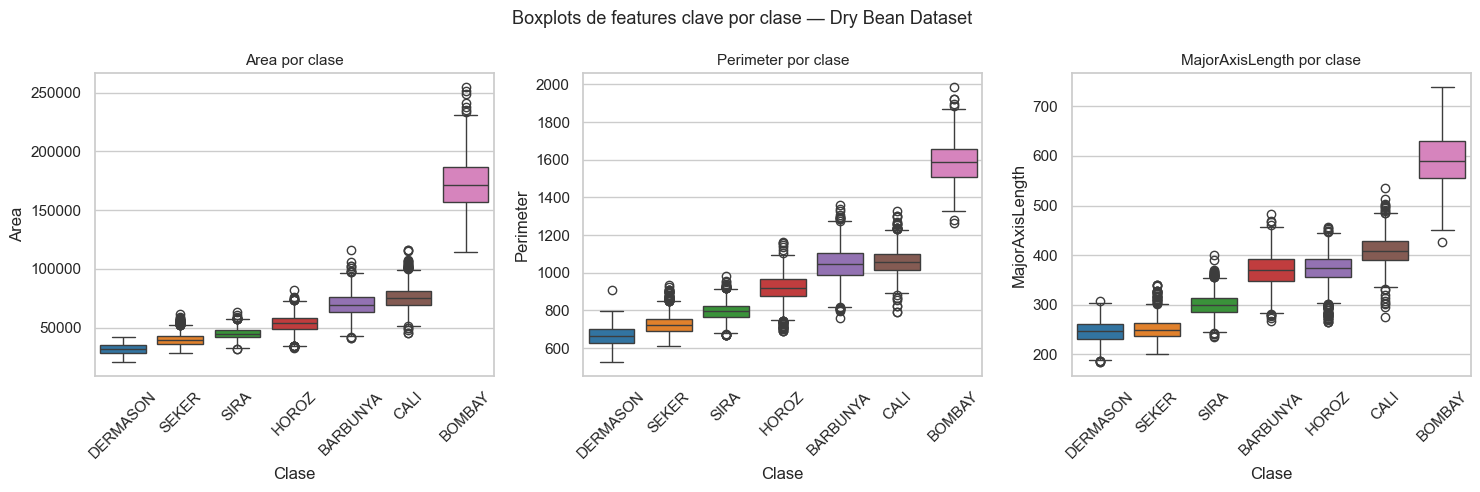

In [10]:
features_clave = ['Area', 'Perimeter', 'MajorAxisLength']

fig, axes = plt.subplots(1, len(features_clave), figsize=(15, 5))

for ax, feature in zip(axes, features_clave):
    # Ordenamos por mediana para que las clases aparezcan de menor a mayor tamaño
    orden = df.groupby('Class')[feature].median().sort_values().index
    sns.boxplot(data=df, x='Class', y=feature, order=orden, ax=ax, palette='tab10')
    ax.set_title(f'{feature} por clase', fontsize=11)
    ax.set_xlabel('Clase')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Boxplots de features clave por clase — Dry Bean Dataset', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'boxplots_por_clase.png', bbox_inches='tight')
plt.show()

Los boxplots confirman que BOMBAY se separa claramente del resto por su tamaño. Las demás clases se mezclan más, especialmente SEKER y BARBUNYA que tienen rangos similares en estas variables. Esto nos da pistas sobre dónde el modelo podría equivocarse, algo que veremos más adelante en la matriz de confusión.

## 7. Conclusiones del EDA

En general el dataset está en buen estado: no tiene valores nulos en ninguna de sus columnas,
lo que nos ahorra bastante trabajo de limpieza. Lo único que encontramos fueron 68 filas repetidas,
que es menos del 1 % del total, y que conviene quitar antes de entrenar el modelo para no enseñarle
dos veces los mismos ejemplos. En cuanto a las clases, no todas tienen la misma cantidad de datos:
DERMASON aparece en el 26 % de los registros mientras que BOMBAY solo está en el 3.84 %.
No es un desbalance extremo, pero sí suficiente para que usemos F1 macro como métrica
y hagamos la partición de datos de forma estratificada, asegurándonos de que cada clase
quede bien representada tanto en entrenamiento como en prueba.

Algo que salta a la vista en las correlaciones es que varias variables miden cosas muy parecidas:
`Area`, `Perimeter`, `MajorAxisLength` y `MinorAxisLength` tienen correlaciones por encima de 0.9,
es decir, prácticamente se mueven juntas. Además, las variables no están en la misma escala:
`Area` llega a valores de cientos de miles, mientras que `Roundness` o `Compactness` van de 0 a 1.
Esto significa que antes de entrenar hay que normalizar los datos, especialmente si usamos
regresión logística. Los boxplots también nos mostraron algo interesante: BOMBAY se diferencia
muy claramente del resto por su tamaño, mientras que SEKER y BARBUNYA se parecen bastante
entre sí, así que es probable que el modelo las confunda con más frecuencia.

Con todo esto, el dataset está listo para pasar a la siguiente etapa. El preprocesamiento
será sencillo: quitar los duplicados y aplicar escalado. Dado lo que vimos visualmente,
un modelo de regresión logística debería dar resultados aceptables como punto de partida,
y un Random Forest probablemente mejore eso al manejar mejor las correlaciones entre variables.